In [1]:
! pip install --upgrade xarray zarr gcsfs cftime nc-time-axis

In [4]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import zarr
import gcsfs

xr.set_options(display_style='html')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [5]:
print(zarr.__version__)

2.18.3


In [6]:
plt.rcParams['figure.figsize'] = 12, 6

In [7]:
df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
df.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706


In [8]:
df['activity_id'].unique()

<ArrowStringArray>
[ 'HighResMIP',        'CMIP',       'CFMIP', 'ScenarioMIP',  'AerChemMIP',
       'RFMIP',      'FAFMIP',       'DAMIP',       'LUMIP',      'CDRMIP',
       'GMMIP',       'C4MIP',        'OMIP',        'PMIP',      'LS3MIP',
        'DCPP',       'PAMIP',      'ISMIP6']
Length: 18, dtype: str

In [9]:
variables = pd.read_csv("data/cmip6_variables.csv")

In [10]:
variables.head()

,variable_id,description,table_id(s)
0,abs550aer,Ambient Aerosol Absorption Optical Thickness a...,AERmon
1,acabfIs,Ice Sheet Surface Mass Balance Flux [kg m-2 s-1],LImon
2,acabf,Surface Mass Balance Flux [kg m-2 s-1],"ImonAnt, ImonGre"
3,agesno,Mean Age of Snow [day],"Eday, LImon"
4,agessc,Sea Water Age Since Surface Contact [yr],"Odec, Omon"


In [11]:
data = pd.read_csv("data/cmip_data.csv")

In [12]:
data

,Unnamed: 0,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,101,CMIP,MOHC,HadGEM3-GC31-MM,piControl,r1i1p1f1,Amon,rsdt,gn,gs://cmip6/CMIP6/CMIP/MOHC/HadGEM3-GC31-MM/piC...,NaN,20170831
1,520,CMIP,NOAA-GFDL,GFDL-CM4,historical,r1i1p1f1,AERmon,emidust,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/histo...,NaN,20180301
2,521,CMIP,NOAA-GFDL,GFDL-CM4,historical,r1i1p1f1,AERmon,emiss,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/histo...,NaN,20180301
3,522,CMIP,NOAA-GFDL,GFDL-CM4,historical,r1i1p1f1,AERmon,mmrbc,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/histo...,NaN,20180301
4,523,CMIP,NOAA-GFDL,GFDL-CM4,historical,r1i1p1f1,AERmon,mmrdust,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/histo...,NaN,20180301
...,...,...,...,...,...,...,...,...,...,...,...,...
137393,523769,CMIP,EC-Earth-Consortium,EC-Earth3-Veg,historical,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/CMIP/EC-Earth-Consortium/EC-E...,NaN,20211207
137394,523770,CMIP,EC-Earth-Consortium,EC-Earth3-Veg,historical,r1i1p1f1,Amon,tauu,gr,gs://cmip6/CMIP6/CMIP/EC-Earth-Consortium/EC-E...,NaN,20211207
137395,523771,CMIP,EC-Earth-Consortium,EC-Earth3-Veg,historical,r1i1p1f1,Amon,hur,gr,gs://cmip6/CMIP6/CMIP/EC-Earth-Consortium/EC-E...,NaN,20211207
137396,523772,CMIP,EC-Earth-Consortium,EC-Earth3-Veg,historical,r1i1p1f1,Amon,hus,gr,gs://cmip6/CMIP6/CMIP/EC-Earth-Consortium/EC-E...,NaN,20211207


In [13]:
ocean_data = df.query("table_id == 'Omon' & experiment_id == 'historical'")

In [14]:
ocean_data

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
963,CMIP,NOAA-GFDL,GFDL-ESM4,historical,r3i1p1f1,Omon,wfo,gr,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/hist...,NaN,20180701
964,CMIP,NOAA-GFDL,GFDL-ESM4,historical,r3i1p1f1,Omon,zos,gn,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/hist...,NaN,20180701
965,CMIP,NOAA-GFDL,GFDL-ESM4,historical,r3i1p1f1,Omon,zos,gr,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/hist...,NaN,20180701
975,CMIP,NOAA-GFDL,GFDL-ESM4,historical,r2i1p1f1,Omon,wfo,gr,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/hist...,NaN,20180701
976,CMIP,NOAA-GFDL,GFDL-ESM4,historical,r2i1p1f1,Omon,zos,gn,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/hist...,NaN,20180701
...,...,...,...,...,...,...,...,...,...,...,...
523553,CMIP,MRI,MRI-ESM2-0,historical,r7i1p1f1,Omon,so,gr,gs://cmip6/CMIP6/CMIP/MRI/MRI-ESM2-0/historica...,NaN,20210909
523556,CMIP,MRI,MRI-ESM2-0,historical,r8i1p1f1,Omon,so,gr,gs://cmip6/CMIP6/CMIP/MRI/MRI-ESM2-0/historica...,NaN,20210909
523557,CMIP,MRI,MRI-ESM2-0,historical,r9i1p1f1,Omon,so,gn,gs://cmip6/CMIP6/CMIP/MRI/MRI-ESM2-0/historica...,NaN,20210909
523558,CMIP,MRI,MRI-ESM2-0,historical,r9i1p1f1,Omon,so,gr,gs://cmip6/CMIP6/CMIP/MRI/MRI-ESM2-0/historica...,NaN,20210909


In [15]:
fs = gcsfs.GCSFileSystem(token="anon")

tos_df = ocean_data[
    (ocean_data["variable_id"] == "tos") &
    (ocean_data["table_id"] == "Omon") &
    (ocean_data["experiment_id"] == "historical")
].drop_duplicates(subset="source_id")
tos_df

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
995,CMIP,NOAA-GFDL,GFDL-ESM4,historical,r3i1p1f1,Omon,tos,gr,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/hist...,NaN,20180701
9976,CMIP,NOAA-GFDL,GFDL-CM4,historical,r1i1p1f1,Omon,tos,gr,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/histo...,NaN,20180701
22198,CMIP,IPSL,IPSL-CM6A-LR,historical,r8i1p1f1,Omon,tos,gn,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...,NaN,20180803
32357,CMIP,NASA-GISS,GISS-E2-1-G,historical,r1i1p1f1,Omon,tos,gn,gs://cmip6/CMIP6/CMIP/NASA-GISS/GISS-E2-1-G/hi...,NaN,20180827
37663,CMIP,CNRM-CERFACS,CNRM-CM6-1,historical,r1i1p1f2,Omon,tos,gr1,gs://cmip6/CMIP6/CMIP/CNRM-CERFACS/CNRM-CM6-1/...,NaN,20180917
41240,CMIP,BCC,BCC-CSM2-MR,historical,r2i1p1f1,Omon,tos,gn,gs://cmip6/CMIP6/CMIP/BCC/BCC-CSM2-MR/historic...,NaN,20181031
43554,CMIP,BCC,BCC-ESM1,historical,r1i1p1f1,Omon,tos,gn,gs://cmip6/CMIP6/CMIP/BCC/BCC-ESM1/historical/...,NaN,20181129
44004,CMIP,CNRM-CERFACS,CNRM-ESM2-1,historical,r1i1p1f2,Omon,tos,gr1,gs://cmip6/CMIP6/CMIP/CNRM-CERFACS/CNRM-ESM2-1...,NaN,20181206
44372,CMIP,MIROC,MIROC6,historical,r9i1p1f1,Omon,tos,gn,gs://cmip6/CMIP6/CMIP/MIROC/MIROC6/historical/...,NaN,20181212
45550,CMIP,AWI,AWI-CM-1-1-MR,historical,r2i1p1f1,Omon,tos,gn,gs://cmip6/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/histor...,NaN,20181218


dataset opened, now computing...


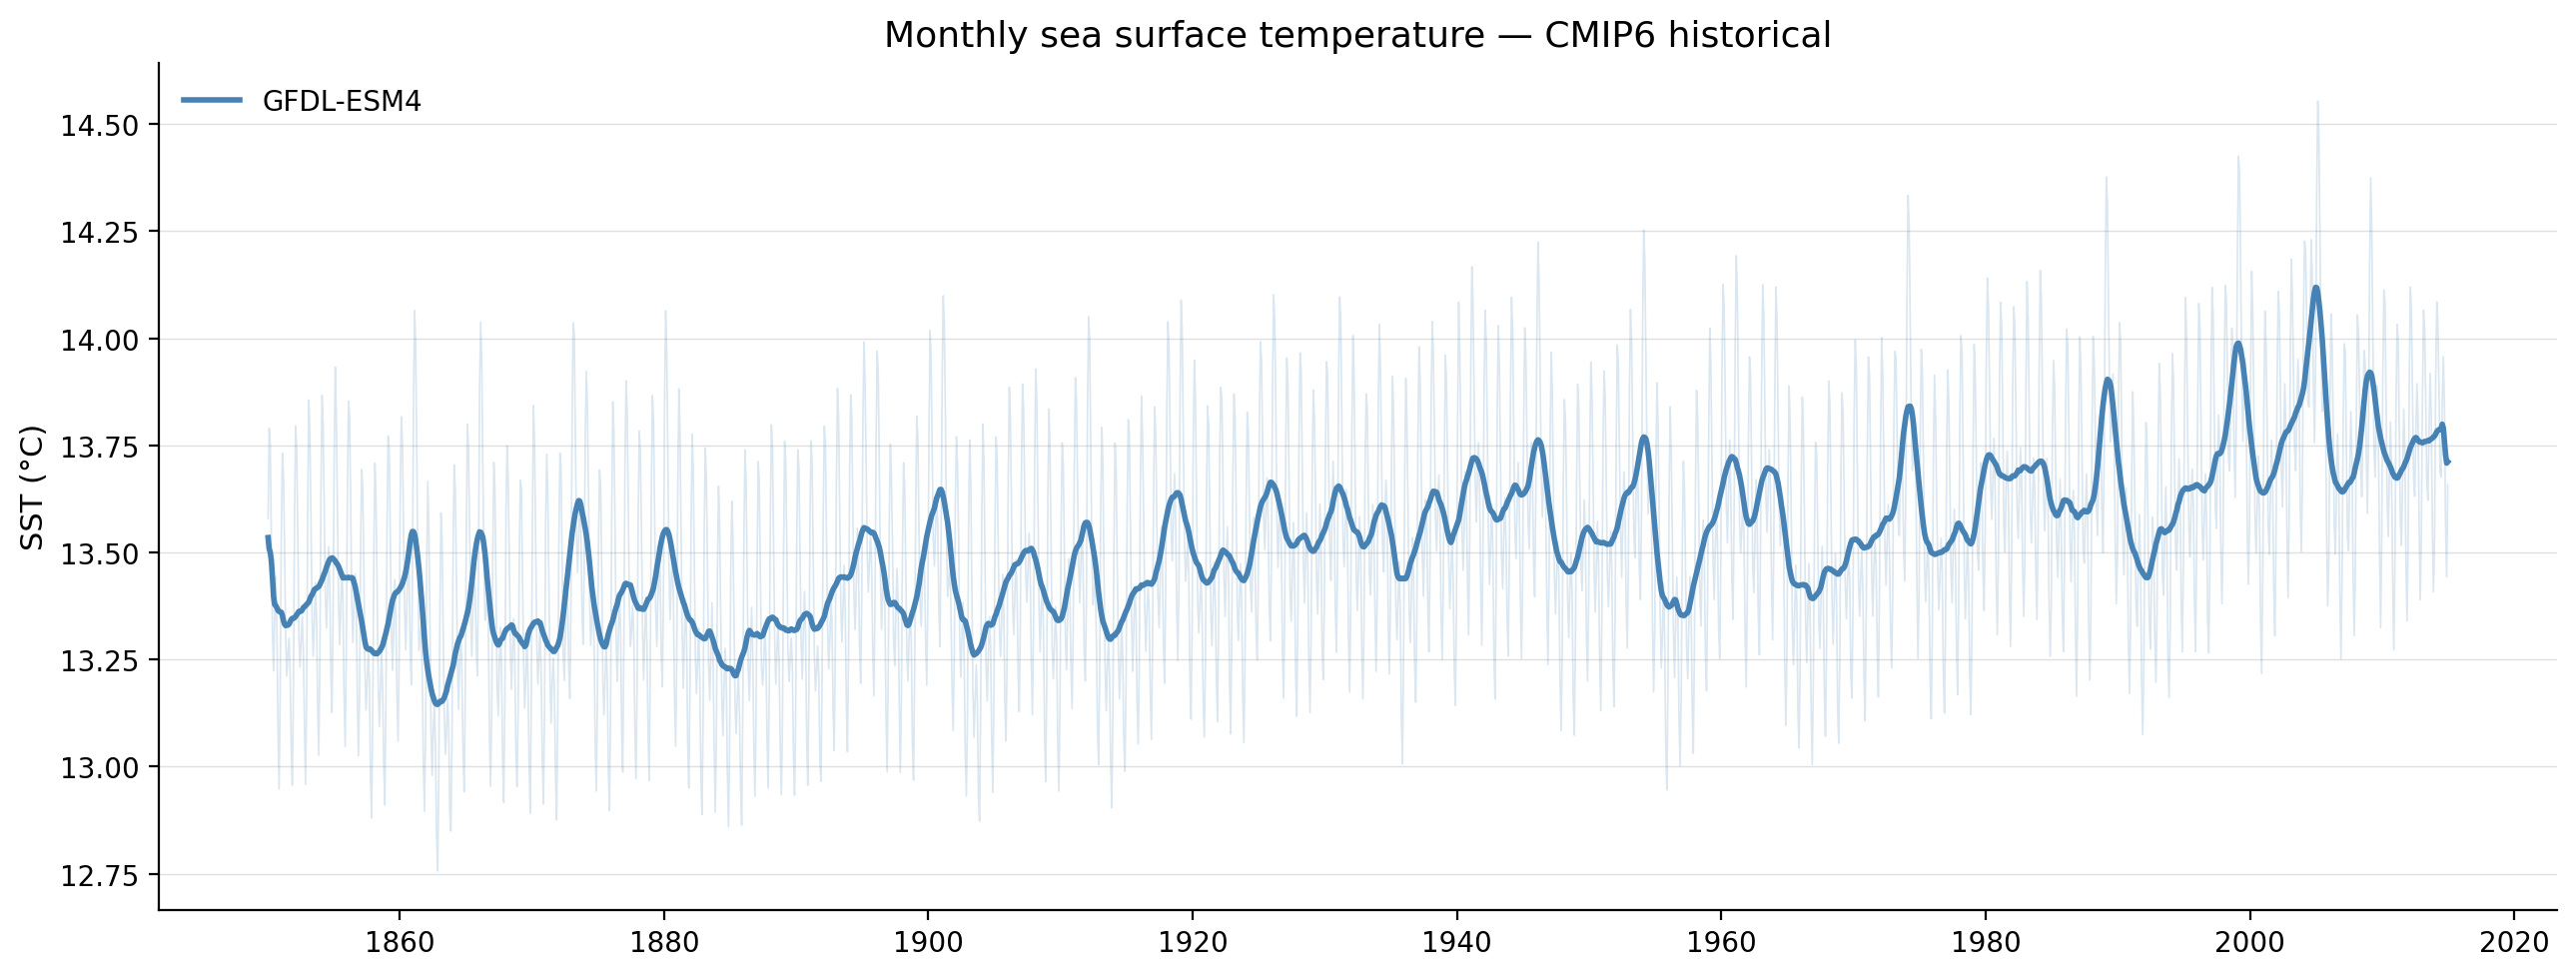

In [16]:
# just grab the one model that worked
row = tos_df[tos_df["source_id"] == "MIROC6"].iloc[0]  # replace with whichever model said OK

store = fs.get_mapper(row["zstore"])
ds = xr.open_zarr(store, consolidated=False)
tos = ds["tos"]
print("dataset opened, now computing...")
lat_dims = [d for d in tos.dims if d in ["lat", "latitude", "nlat", "j", "y"]]
lon_dims = [d for d in tos.dims if d in ["lon", "longitude", "nlon", "i", "x"]]
ts = tos.mean(dim=lat_dims + lon_dims).compute()

units = tos.attrs.get("units", "")
if "K" in units or ts.values[0] > 100:
    ts = ts - 273.15

# plot
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts.time, ts.values, linewidth=0.6, alpha=0.2, color="steelblue")
ax.plot(
    ts.time,
    ts.rolling(time=12, center=True, min_periods=6).mean().values,
    linewidth=2,
    color="steelblue",
    label="GFDL-ESM4"  # replace with your model name
)
ax.set_ylabel("SST (°C)", fontsize=11)
ax.set_title("Monthly sea surface temperature — CMIP6 historical", fontsize=13, fontweight="normal")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linewidth=0.5, color="#e0e0e0")
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

In [17]:
print(ocean_data[
    (ocean_data["source_id"] == "MIROC6") &
    (ocean_data["table_id"] == "Omon")
]["variable_id"].unique())

<ArrowStringArray>
[    'sos',     'zos',     'tos',      'wo',      'so',  'thetao',      'uo',
      'vo', 'zostoga', 'hfbasin',  'msftmz',  'rsntds',   'tauvo',   'tauuo',
     'wfo',     'umo',   'sfdsi',    'hfds',     'vmo',     'wmo']
Length: 20, dtype: str


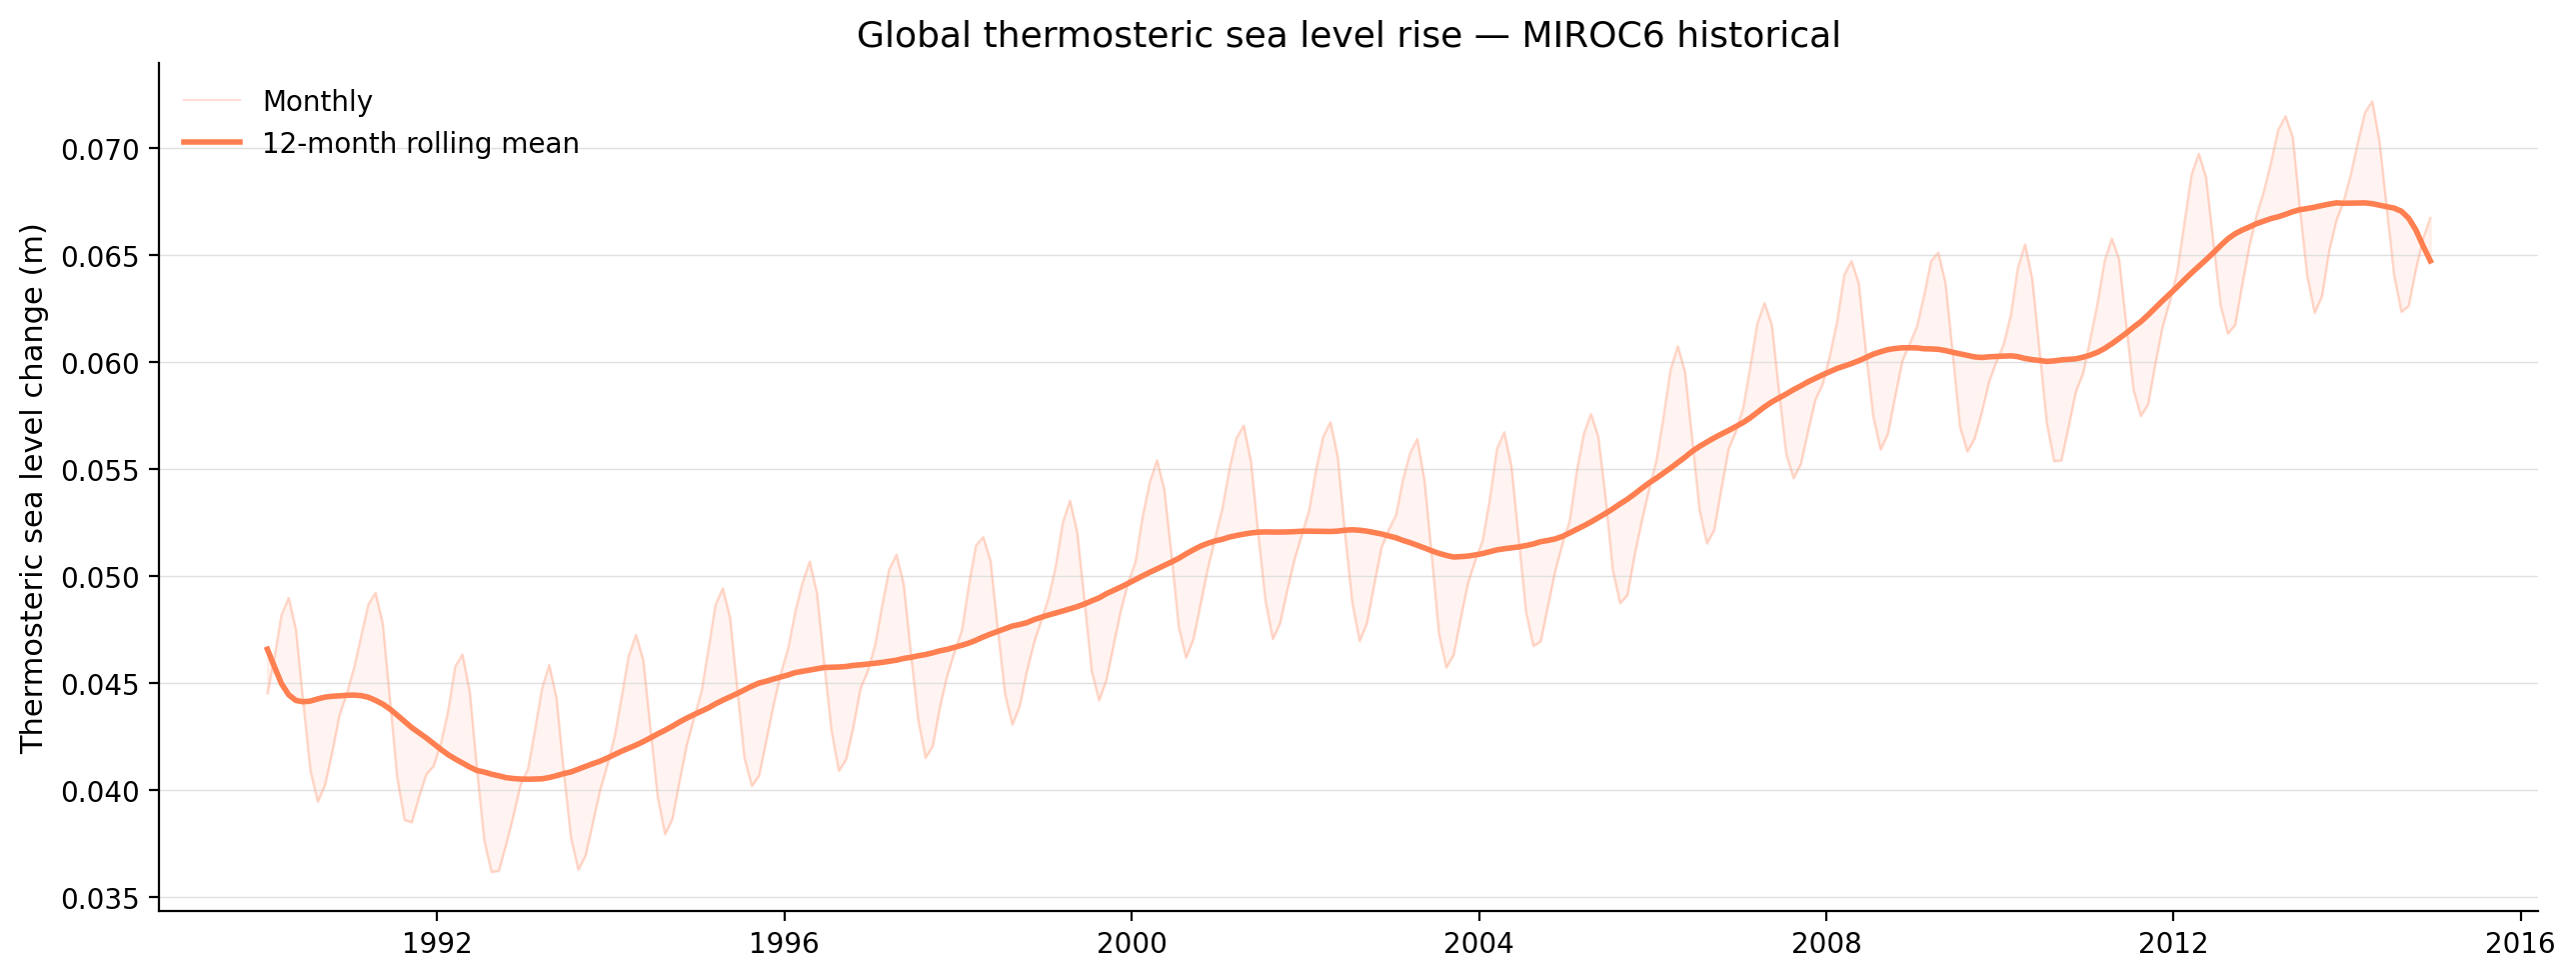

In [18]:
row = ocean_data[
    (ocean_data["source_id"] == "MIROC6") &
    (ocean_data["variable_id"] == "zostoga") &
    (ocean_data["table_id"] == "Omon") &
    (ocean_data["experiment_id"] == "historical")
].iloc[0]

store = fs.get_mapper(row["zstore"])
ds = xr.open_zarr(store, consolidated=False)

# short time range to test quickly
ts_zostoga = ds["zostoga"].sel(time=slice("1990", "2015")).compute()

trend = ts_zostoga.rolling(time=12, center=True, min_periods=6).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts_zostoga.time, ts_zostoga.values, linewidth=0.8, alpha=0.25, color="coral", label="Monthly")
ax.plot(ts_zostoga.time, trend.values, linewidth=2, color="coral", label="12-month rolling mean")
ax.fill_between(ts_zostoga.time.values, ts_zostoga.values, trend.values, alpha=0.08, color="coral")

ax.set_ylabel("Thermosteric sea level change (m)", fontsize=11)
ax.set_title("Global thermosteric sea level rise — MIROC6 historical", fontsize=13, fontweight="normal")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linewidth=0.5, color="#e0e0e0")
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

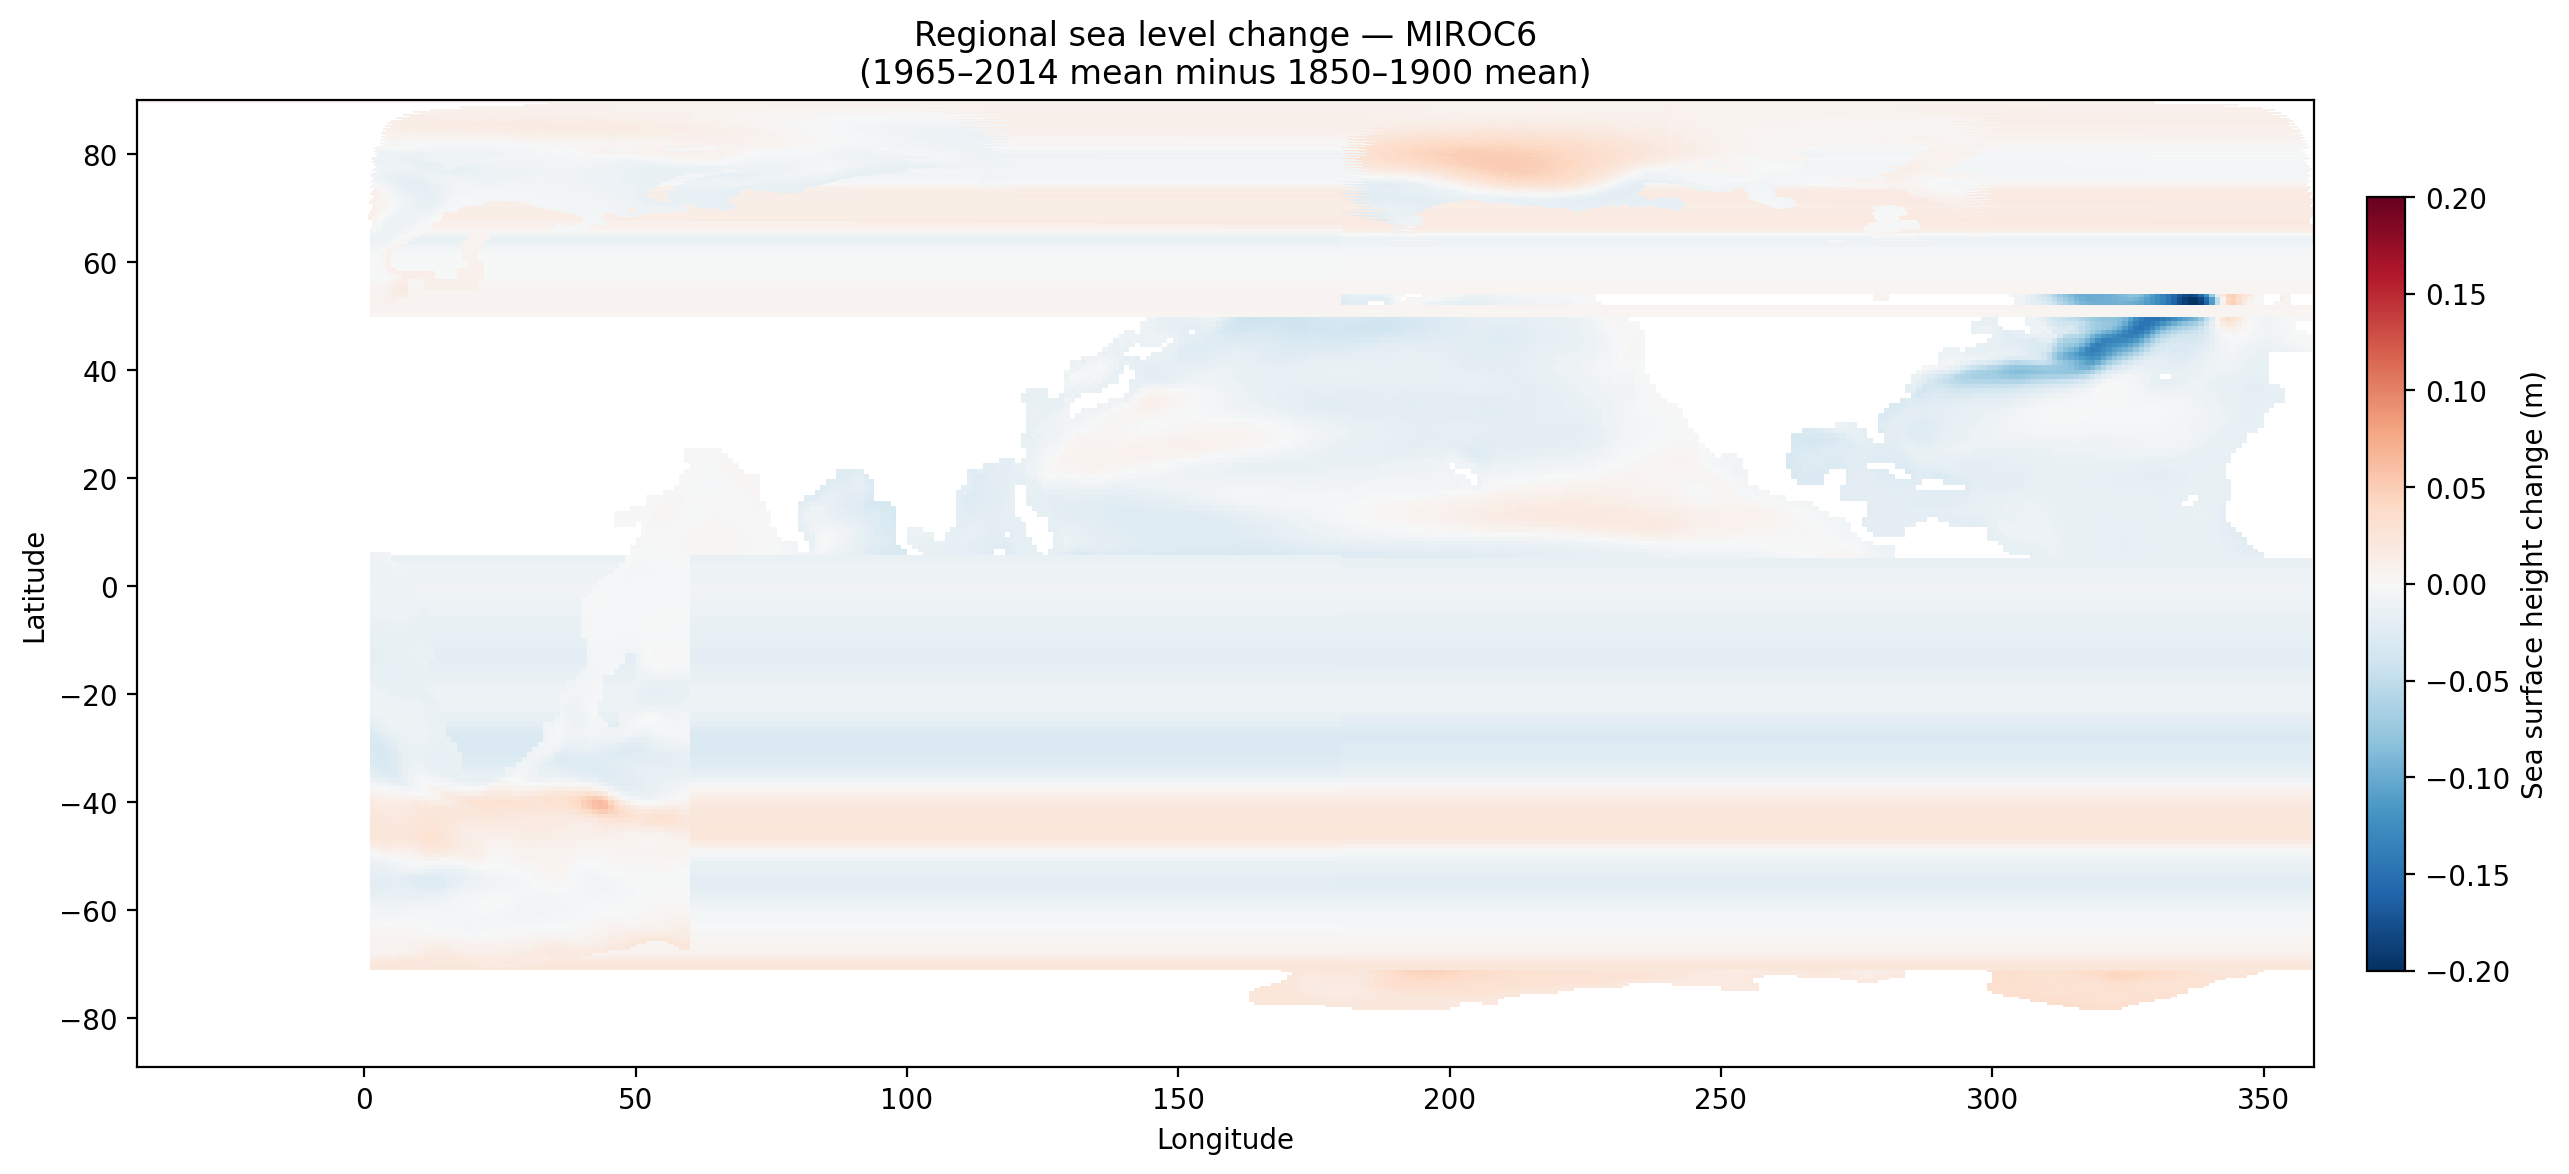

In [25]:
import warnings
lat_coord = [c for c in diff.coords if c in ["lat","latitude","y","j"]][0]
lon_coord = [c for c in diff.coords if c in ["lon","longitude","x","i"]][0]

diff_clean = diff.where(diff < 0.5).where(diff > -0.5)

fig, ax = plt.subplots(figsize=(14, 6))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    im = ax.pcolormesh(
        diff_clean.coords[lon_coord],
        diff_clean.coords[lat_coord],
        diff_clean.values,
        cmap="RdBu_r",
        vmin=-0.2, vmax=0.2
    )

cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02, shrink=0.8)
cbar.set_label("Sea surface height change (m)", fontsize=10)
ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude", fontsize=10)
ax.set_title("Regional sea level change — MIROC6\n(1965–2014 mean minus 1850–1900 mean)",
             fontsize=12, fontweight="normal")
plt.tight_layout()
plt.show()